<a href="https://colab.research.google.com/github/Yurii1960/goit-algo-hw-04/blob/main/Hw2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Download latest version
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")


print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


In [ ]:
import pandas as pd
df = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))
print(df)

                                                  Name  \
0                        10-Day Green Smoothie Cleanse   
1                                    11/22/63: A Novel   
2              12 Rules for Life: An Antidote to Chaos   
3                               1984 (Signet Classics)   
4    5,000 Awesome Facts (About Everything!) (Natio...   
..                                                 ...   
545       Wrecking Ball (Diary of a Wimpy Kid Book 14)   
546  You Are a Badass: How to Stop Doubting Your Gr...   
547  You Are a Badass: How to Stop Doubting Your Gr...   
548  You Are a Badass: How to Stop Doubting Your Gr...   
549  You Are a Badass: How to Stop Doubting Your Gr...   

                       Author  User Rating  Reviews  Price  Year        Genre  
0                    JJ Smith          4.7    17350      8  2016  Non Fiction  
1                Stephen King          4.6     2052     22  2011      Fiction  
2          Jordan B. Peterson          4.7    18979     15  201

In [ ]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [ ]:
df.shape

(550, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [ ]:
df['Name'].duplicated().sum()

np.int64(199)

In [ ]:
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        550 non-null    object 
 1   author      550 non-null    object 
 2   userrating  550 non-null    float64
 3   reviews     550 non-null    int64  
 4   price       550 non-null    int64  
 5   year        550 non-null    int64  
 6   genre       550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [ ]:
df.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

550-199=349 оригінальних книг

In [ ]:
columns_name=df.columns
small_name=[]
for col in columns_name:
  col=col.lower().replace(' ','')
  small_name.append(col)

data=pd.Series(small_name)

df.columns=data
df.head(1)





,name,author,userrating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction


In [ ]:
df.isna().sum()

,0
name,0
author,0
userrating,0
reviews,0
price,0
year,0
genre,0


 у ставпцях пропусків немає

In [ ]:
#унікальні жанри
print(df['genre'].unique())

['Non Fiction' 'Fiction']


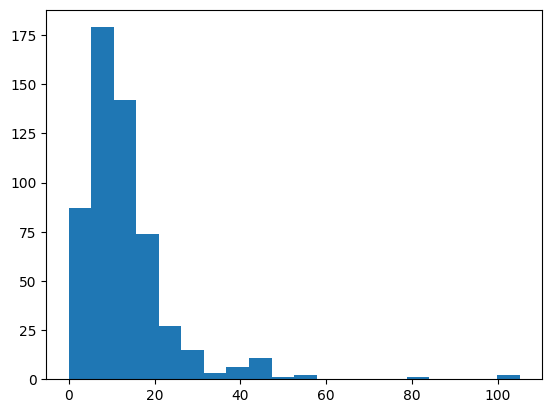

In [ ]:
import matplotlib.pyplot as plt
data=df['price']
plt.hist(data,bins=20)
plt.show()

In [ ]:
df['price'].agg(['min','max','mean','median'])

,price
min,0.0
max,105.0
mean,13.1
median,11.0


мінімальна ціна 0, макс.105, середня 13.1, медіанна 11

In [ ]:
df['userrating'].max()

4.9

найвищий рейтинг 4.9

In [ ]:
df.loc[df['userrating']==df['userrating'].max()]['name'].shape

(52,)

найвищий рейтинг має 52 книги

In [ ]:
df[df['reviews']==df['reviews'].max()]['name']

,name
534,Where the Crawdads Sing


найбільше відгуків має книга
name
534	Where the Crawdads Sing


In [ ]:
max_price = df[df['year'] == 2015]['price'].max()
df[(df['year'] == 2015) & (df['price'] == max_price)]['name']

,name
277,Publication Manual of the American Psychologic...


найдорожча книга у 2015 році
name
277	Publication Manual of the American Psychologic...

In [ ]:
df[(df['year'] == 2010) & (df['genre'] == 'Fiction')]['name'].shape

(20,)

до рейтингу потрапило 20 книг Fiction

In [ ]:
#df.duplicated(subset='name').sum()

df1=df.drop_duplicates(subset='name')
df1



,name,author,userrating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
538,Winter of the World: Book Two of the Century T...,Ken Follett,4.5,10760,15,2012,Fiction
539,Women Food and God: An Unexpected Path to Almo...,Geneen Roth,4.2,1302,11,2010,Non Fiction
540,Wonder,R. J. Palacio,4.8,21625,9,2013,Fiction
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction


In [ ]:
df[((df['year'] == 2010) | (df['year'] == 2011))  & (df['userrating'] == 4.9)]['name'].shape

(1,)

у 2010 та 2010 році з рейтингом 4.9 до топ рейтингу потрапило 1 книга

In [ ]:
df1=df[(df['year'] == 2015) & (df['price'] < 8)].sort_values(by='price').tail(1)['name']
df1

,name
253,Old School (Diary of a Wimpy Kid #10)


останньою книгою у списку є книга Old School (Diary of a Wimpy

In [ ]:
df.groupby('genre')['price'].agg(['min','max'])

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


мін ціна для обох жанрів 0,максим. для Fiction -82, для
min	max
genre
Fiction	0	82
Non Fiction -105

In [ ]:
autor_books=df.groupby('author')['name'].count()
autor_books.sort_values(ascending=False)

,name
author,
Jeff Kinney,12
Gary Chapman,11
Rick Riordan,11
Suzanne Collins,11
American Psychological Association,10
...,...
Thomas Piketty,1
The Washington Post,1
Tina Fey,1


In [ ]:
autor_books.shape

(248,)

розміність нової таблиці (рядка) - 248 на 1

найбільше книг має Jeff Kinney	12

In [ ]:
autors_mean_rating=df.groupby('author')['userrating'].mean()
autors_mean_rating.sort_values()

,userrating
author,
Donna Tartt,3.9
Gallup,4.0
Gillian Flynn,4.0
Muriel Barbery,4.0
Ian K. Smith M.D.,4.1
...,...
Lin-Manuel Miranda,4.9
Patrick Thorpe,4.9
Sarah Young,4.9


мінімальний рейтинг має Donna Tartt

In [ ]:
concat_info=pd.concat([autor_books,autors_mean_rating],axis=1)
concat_info

,name,userrating
author,,
Abraham Verghese,2,4.600000
Adam Gasiewski,1,4.400000
Adam Mansbach,1,4.800000
Adir Levy,1,4.800000
Admiral William H. McRaven,1,4.700000
...,...,...
Walter Isaacson,3,4.566667
William Davis,2,4.400000
William P. Young,2,4.600000


In [ ]:
sort_concat_info=concat_info.sort_values(by=['name','userrating'])
sort_concat_info

,name,userrating
author,,
Muriel Barbery,1,4.000000
Chris Cleave,1,4.100000
Ian K. Smith M.D.,1,4.100000
Pierre Dukan,1,4.100000
Elizabeth Strout,1,4.200000
...,...,...
American Psychological Association,10,4.500000
Suzanne Collins,11,4.663636
Gary Chapman,11,4.736364


першим в списку є Muriel Barbery

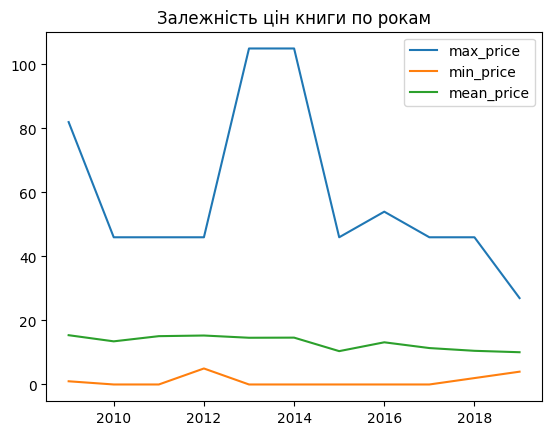

In [ ]:
import matplotlib.pyplot as plt
data=df.groupby('year')['price'].agg(['min','max','mean'])
fig,axs=plt.subplots()
axs.plot(data['max'],label='max_price')
axs.plot(data['min'],label='min_price')
axs.plot(data['mean'],label='mean_price')
plt.legend()
plt.title('Залежність цін книги по рокам')
plt.show()


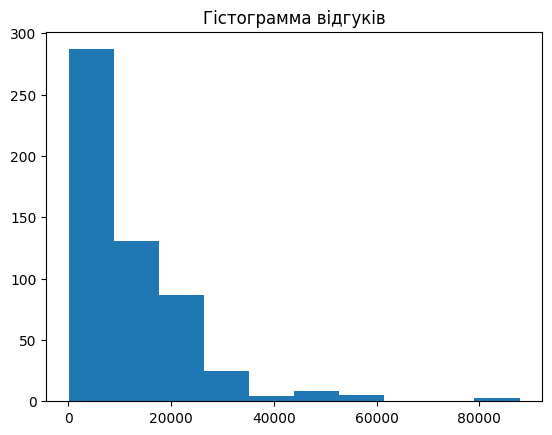

In [ ]:

data=df['reviews']
plt.hist(data,bins=10)
plt.title('Гістограмма відгуків')
plt.show()

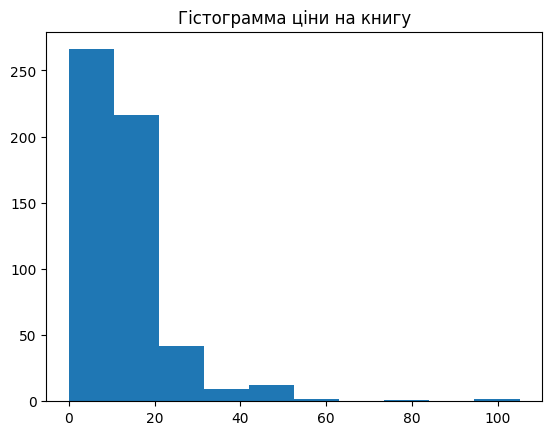

In [ ]:
import matplotlib.pyplot as plt
data=df['price']
plt.title('Гістограмма ціни на книгу')
plt.hist(data,bins=10)
plt.show()

Text(0.5, 1.0, 'Залежність кількості відгуків від ціни по жанрам')

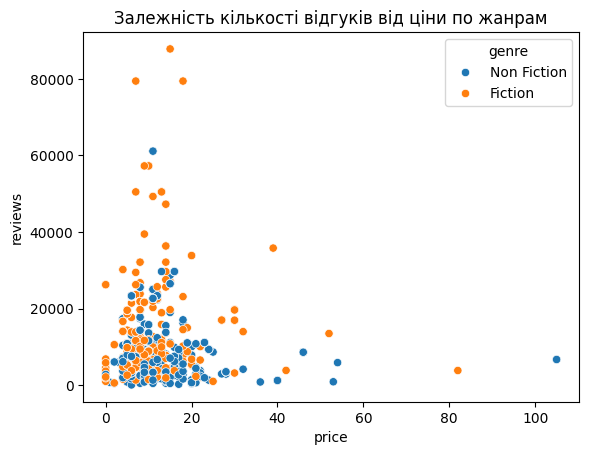

In [ ]:
sns.scatterplot(x='price',y='reviews', hue='genre',data=df)
plt.title('Залежність кількості відгуків від ціни по жанрам')